# 수어 인식 모델 재학습 (D+F+U 각도)
> 얼굴 키포인트 매핑 검증 완료 버전
> D(정면) + F(전면) + U(상단) 각도만 사용 -> 웹캠 환경 최적화

In [ ]:
# 환경 설정 및 GCS 인증 
from google.colab import auth
auth.authenticate_user()

PROJECT_ID  = 'project-id'
BUCKET_NAME = 'sign-language-data-2026'

!gcloud config set project {PROJECT_ID}
print('GCS 인증 완료')

In [ ]:
# 셀 2: 라이브러리 임포트 
import numpy as np
import json
import io
from google.cloud import storage
from collections import defaultdict, Counter
import re

client = storage.Client()
bucket = client.bucket(BUCKET_NAME)
print('라이브러리 로드 완료')

In [ ]:
# 셀 3: label_map 로드 
blob = bucket.blob('processed/label_map.json')
label_map = json.loads(blob.download_as_text())
print(f'label_map 로드 완료: {len(label_map)}개 단어')
print(f'   예시: {list(label_map.items())[:3]}')

In [ ]:
# 셀 4: GCS에서 X_train_DFU.npy 로드 
# preprocess2.ipynb에서 이미 슬라이싱 완료된 파일 사용
import numpy as np
import io
from google.cloud import storage

client = storage.Client()
bucket = client.bucket('sign-language-data-2026')

def load_npy(blob_name):
    buf = io.BytesIO(bucket.blob(blob_name).download_as_bytes())
    return np.load(buf)

print("GCS에서 X_train_DFU.npy 로드 중...")
X = load_npy("processed/X_train_DFU.npy")  # (9000, 30, 274)
y = load_npy("processed/y_train_DFU.npy")  # (9000,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"클래스 수: {len(np.unique(y))}")


GCS에서 X_train_DFU.npy 로드 중...
X shape: (9000, 30, 274)
y shape: (9000,)
클래스 수: 3000


In [ ]:
# 셀 8: 데이터 로드 및 전처리 
import numpy as np
import io
from google.cloud import storage
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

client = storage.Client()
bucket = client.bucket('sign-language-data-2026')

def load_npy(blob_name):
    buf = io.BytesIO(bucket.blob(blob_name).download_as_bytes())
    return np.load(buf)

X = load_npy('processed/X_train_DFU.npy')  # (N, 30, 274)
y = load_npy('processed/y_train_DFU.npy')  # (N,)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'클래스 수: {len(np.unique(y))}')

X shape: (9000, 30, 274)
y shape: (9000,)
클래스 수: 3000


In [ ]:
# 셀 9: 정규화 + 데이터 분리 
NUM_CLASSES = 3000

# Z-score 정규화
X_mean = X.mean(axis=(0, 1), keepdims=True)  # (1, 1, 274)
X_std  = X.std(axis=(0, 1),  keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

# train / val / test 분리 (70 / 15 / 15)
# stratify 제거 — 샘플 수(9000)가 클래스 수(3000)보다 적어서 불가
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

y_val_cat  = to_categorical(y_val,  NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (6300, 30, 274), Val: (1350, 30, 274), Test: (1350, 30, 274)


In [ ]:
# 셀 10: 데이터 증강 (3배) 

def augment(x):
    noise = np.random.normal(0, 0.01, x.shape)       # 손 떨림
    scale = np.random.uniform(0.9, 1.1)               # 손 크기
    shift = np.random.uniform(-0.05, 0.05)            # 위치 이동
    return x * scale + noise + shift

X_aug1 = np.array([augment(x) for x in X_train])
X_aug2 = np.array([augment(x) for x in X_train])

X_train_final = np.concatenate([X_train, X_aug1, X_aug2], axis=0)
y_train_final = np.concatenate([y_train, y_train, y_train], axis=0)
y_train_final_cat = to_categorical(y_train_final, NUM_CLASSES)

print(f'원본 train: {X_train.shape}')
print(f'증강 후:    {X_train_final.shape}  (3배)')

원본 train: (6300, 30, 274)
증강 후:    (18900, 30, 274)  (3배)


In [ ]:
# 셀 11: 모델 정의
import tensorflow as tf
from tensorflow.keras import layers, models

def positional_encoding(length, depth):
    positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
    dims      = tf.range(depth,  dtype=tf.float32)[tf.newaxis, :]
    angles    = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(depth, tf.float32))
    angles    = tf.concat([tf.sin(angles[:, 0::2]), tf.cos(angles[:, 1::2])], axis=-1)
    return angles[tf.newaxis, :, :]

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = models.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        x    = self.norm1(x + self.drop1(attn, training=training))
        ffn  = self.ffn(x)
        x    = self.norm2(x + self.drop2(ffn,  training=training))
        return x

def build_transformer_model(input_shape=(30, 274), num_classes=3000,
                             embed_dim=128, num_heads=4, ff_dim=256,
                             num_blocks=3, dropout=0.1):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(embed_dim)(inputs)
    x = x + positional_encoding(input_shape[0], embed_dim)
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_transformer_model()
model.summary()
print(f'\nGPU: {tf.config.list_physical_devices("GPU")}')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 274)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 128)        │        35,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3000)           │       771,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,236,664 (4.72 MB)

 Trainable params: 1,236,664 (4.72 MB)

 Non-trainable params: 0 (0.00 B)


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 셀 12: 학습 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
    ]
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        '/content/best_model_DFU.h5',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    X_train_final, y_train_final_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 8.2704e-04 - loss: 7.8627 - top5_acc: 0.0043
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/best_model_DFU.h5



Epoch 1: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.0013 - loss: 7.5735 - top5_acc: 0.0066 - val_accuracy: 0.0000e+00 - val_loss: 7.9090 - val_top5_acc: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0100 - loss: 6.2729 - top5_acc: 0.0404
Epoch 2: val_accuracy improved from 0.00000 to 0.00519, saving model to /content/best_model_DFU.h5



Epoch 2: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0130 - loss: 6.0060 - top5_acc: 0.0552 - val_accuracy: 0.0052 - val_loss: 7.1051 - val_top5_acc: 0.0326 - learning_rate: 0.0010
Epoch 3/100
290/296 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0440 - loss: 4.9018 - top5_acc: 0.1611
Epoch 3: val_accuracy improved from 0.00519 to 0.02222, saving model to /content/best_model_DFU.h5



Epoch 3: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0565 - loss: 4.6670 - top5_acc: 0.1945 - val_accuracy: 0.0222 - val_loss: 6.1772 - val_top5_acc: 0.1126 - learning_rate: 0.0010
Epoch 4/100
290/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1187 - loss: 3.8233 - top5_acc: 0.3484
Epoch 4: val_accuracy improved from 0.02222 to 0.07630, saving model to /content/best_model_DFU.h5



Epoch 4: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1386 - loss: 3.6488 - top5_acc: 0.3941 - val_accuracy: 0.0763 - val_loss: 5.6673 - val_top5_acc: 0.2356 - learning_rate: 0.0010
Epoch 5/100
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2397 - loss: 2.9172 - top5_acc: 0.5766
Epoch 5: val_accuracy improved from 0.07630 to 0.12148, saving model to /content/best_model_DFU.h5


...


Epoch 38: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9991 - loss: 0.0049 - top5_acc: 1.0000 - val_accuracy: 0.7556 - val_loss: 4.0320 - val_top5_acc: 0.8778 - learning_rate: 1.2500e-04
Epoch 39/100
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9985 - loss: 0.0056 - top5_acc: 1.0000
Epoch 39: val_accuracy did not improve from 0.75556
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9988 - loss: 0.0055 - top5_acc: 1.0000 - val_accuracy: 0.7333 - val_loss: 4.0939 - val_top5_acc: 0.8778 - learning_rate: 1.2500e-04
Epoch 40/100
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9982 - loss: 0.0062 - top5_acc: 1.0000
Epoch 40: val_accuracy did not improve from 0.75556
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9985 - loss: 0.0061 - top5_acc: 1.0000 - val_accuracy: 0.7467 - val_loss: 4.1520 - val_top5_acc: 0.8756 - learning_rate: 1.2500e-04
Epoch 41/100
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 


Epoch 45: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9994 - loss: 0.0033 - top5_acc: 1.0000 - val_accuracy: 0.7615 - val_loss: 4.0878 - val_top5_acc: 0.8778 - learning_rate: 6.2500e-05
Epoch 46/100
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9999 - loss: 0.0024 - top5_acc: 1.0000
Epoch 46: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 46: val_accuracy did not improve from 0.76148
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9997 - loss: 0.0027 - top5_acc: 1.0000 - val_accuracy: 0.7585 - val_loss: 4.0632 - val_top5_acc: 0.8793 - learning_rate: 6.2500e-05
Epoch 47/100
291/296 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9998 - loss: 0.0023 - top5_acc: 1.0000
Epoch 47: val_accuracy did not improve from 0.76148
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9997 - loss: 0.0023 - top5_acc: 1.0000 - val_accuracy: 0.7607 - val_loss: 4.0555 - val_top5_acc: 0.8807 - l


Epoch 49: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9996 - loss: 0.0024 - top5_acc: 1.0000 - val_accuracy: 0.7630 - val_loss: 4.0875 - val_top5_acc: 0.8770 - learning_rate: 3.1250e-05
Epoch 50/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9993 - loss: 0.0028 - top5_acc: 1.0000
Epoch 50: val_accuracy did not improve from 0.76296
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9996 - loss: 0.0024 - top5_acc: 1.0000 - val_accuracy: 0.7600 - val_loss: 4.0939 - val_top5_acc: 0.8793 - learning_rate: 3.1250e-05
Epoch 51/100
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0019 - top5_acc: 1.0000
Epoch 51: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 51: val_accuracy improved from 0.76296 to 0.76667, saving model to /content/best_model_DFU.h5



Epoch 51: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9998 - loss: 0.0023 - top5_acc: 1.0000 - val_accuracy: 0.7667 - val_loss: 4.0722 - val_top5_acc: 0.8785 - learning_rate: 3.1250e-05
Epoch 52/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9999 - loss: 0.0020 - top5_acc: 1.0000
Epoch 52: val_accuracy improved from 0.76667 to 0.76889, saving model to /content/best_model_DFU.h5



Epoch 52: finished saving model to /content/best_model_DFU.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9999 - loss: 0.0020 - top5_acc: 1.0000 - val_accuracy: 0.7689 - val_loss: 4.1073 - val_top5_acc: 0.8770 - learning_rate: 1.5625e-05
Epoch 53/100
293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0021 - top5_acc: 1.0000
Epoch 53: val_accuracy did not improve from 0.76889
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9995 - loss: 0.0021 - top5_acc: 1.0000 - val_accuracy: 0.7622 - val_loss: 4.1622 - val_top5_acc: 0.8770 - learning_rate: 1.5625e-05
Epoch 54/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9998 - loss: 0.0022 - top5_acc: 1.0000
Epoch 54: val_accuracy did not improve from 0.76889
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9998 - loss: 0.0020 - top5_acc: 1.0000 - val_accuracy: 0.7667 - val_loss: 4.1332 - val_top5_acc: 0.8778 - learning_rate: 1.5625e-05
Epoch 55/100
293/296 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - 


[최종 성능]
  Test Top-1: 0.7563 (75.6%)
  Test Top-5: 0.8919 (89.2%)


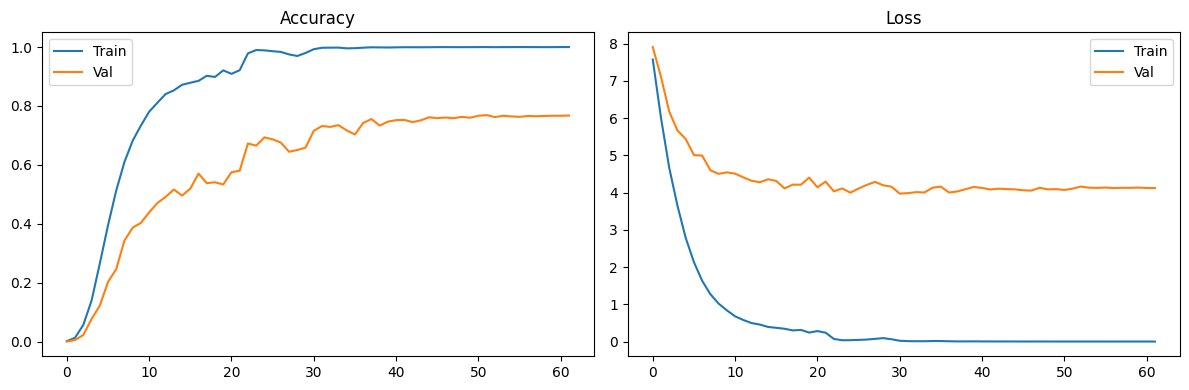

In [ ]:
# 셀 13: 평가 및 시각화 
import matplotlib.pyplot as plt

test_loss, test_acc, test_top5 = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\n[최종 성능]')
print(f'  Test Top-1: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'  Test Top-5: {test_top5:.4f} ({test_top5*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curve_DFU.png', dpi=150)
plt.show()

In [ ]:
# 셀 14: GCS 저장 
import json
from google.cloud import storage

client = storage.Client()
bucket = client.bucket('sign-language-data-2026')

def upload_to_gcs(local_path, blob_name):
    bucket.blob(blob_name).upload_from_filename(local_path)
    print(f'  ✅ {blob_name}')

# 정규화 파라미터 저장 
np.save('/content/X_mean_DFU.npy', X_mean)
np.save('/content/X_std_DFU.npy',  X_std)

print('GCS 업로드 중...')
upload_to_gcs('/content/best_model_DFU.h5',       'models/lstm_model_DFU.h5')
upload_to_gcs('/content/X_mean_DFU.npy',          'models/X_mean_DFU.npy')
upload_to_gcs('/content/X_std_DFU.npy',           'models/X_std_DFU.npy')
upload_to_gcs('/content/training_curve_DFU.png',  'models/training_curve_DFU.png')

print('\n 모든 파일 GCS 업로드 완료!')
print('   모델: models/lstm_model_DFU.h5')
print('   평균: models/X_mean_DFU.npy')
print('   표준편차: models/X_std_DFU.npy')

In [ ]:
# 셀 15: 가중치 로컬 다운로드 (FastAPI용) 
# 학습 완료 후 model_weights.weights.h5 로컬에 저장
model.save_weights('/content/model_weights_DFU.weights.h5')

from google.colab import files
files.download('/content/model_weights_DFU.weights.h5')
files.download('/content/X_mean_DFU.npy')
files.download('/content/X_std_DFU.npy')

print('로컬 다운로드 완료')
print('   → C:/sign-language-api/ 에 복사 후 predict.py 경로 수정 필요')

In [ ]:
# 셀 16: predict.py 업데이트용 추론 테스트 
import json

blob = bucket.blob('processed/label_map.json')
label_map = json.loads(blob.download_as_text())

def predict_word(keypoints_30x274, top_k=5):
    """
    keypoints_30x274: (30, 274) 픽셀 좌표 (1920×1080 스케일)
    """
    x = (keypoints_30x274 - X_mean[0]) / (X_std[0] + 1e-8)
    x = x[np.newaxis, ...]
    probs = model.predict(x, verbose=0)[0]
    top_indices = probs.argsort()[-top_k:][::-1]
    return [(label_map[str(i + 1)], float(probs[i])) for i in top_indices]

# 테스트 샘플 (역정규화 후 추론)
sample_raw = X_test[0] * X_std[0] + X_mean[0]
results    = predict_word(sample_raw)
true_label = label_map[str(int(y_test[0]) + 1)]

print(f'정답: {true_label}')
print('예측 Top-5:')
for word, prob in results:
    mark = '○' if word == true_label else '  '
    print(f'  {mark} {word}: {prob:.4f}')